In [ ]:
# Importy
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ISLP import load_data
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from ISLP.models import ModelSpec as MS, summarize, poly

# Načtení dat
auto = load_data("Auto")
auto.columns

# Vytvořit model
X = sm.add_constant(auto["horsepower"])
y = auto["mpg"]

model = sm.OLS(y, X)
results = model.fit()

summarize(results)

,coef,std err,t,P>|t|
const,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


In [2]:
auto.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


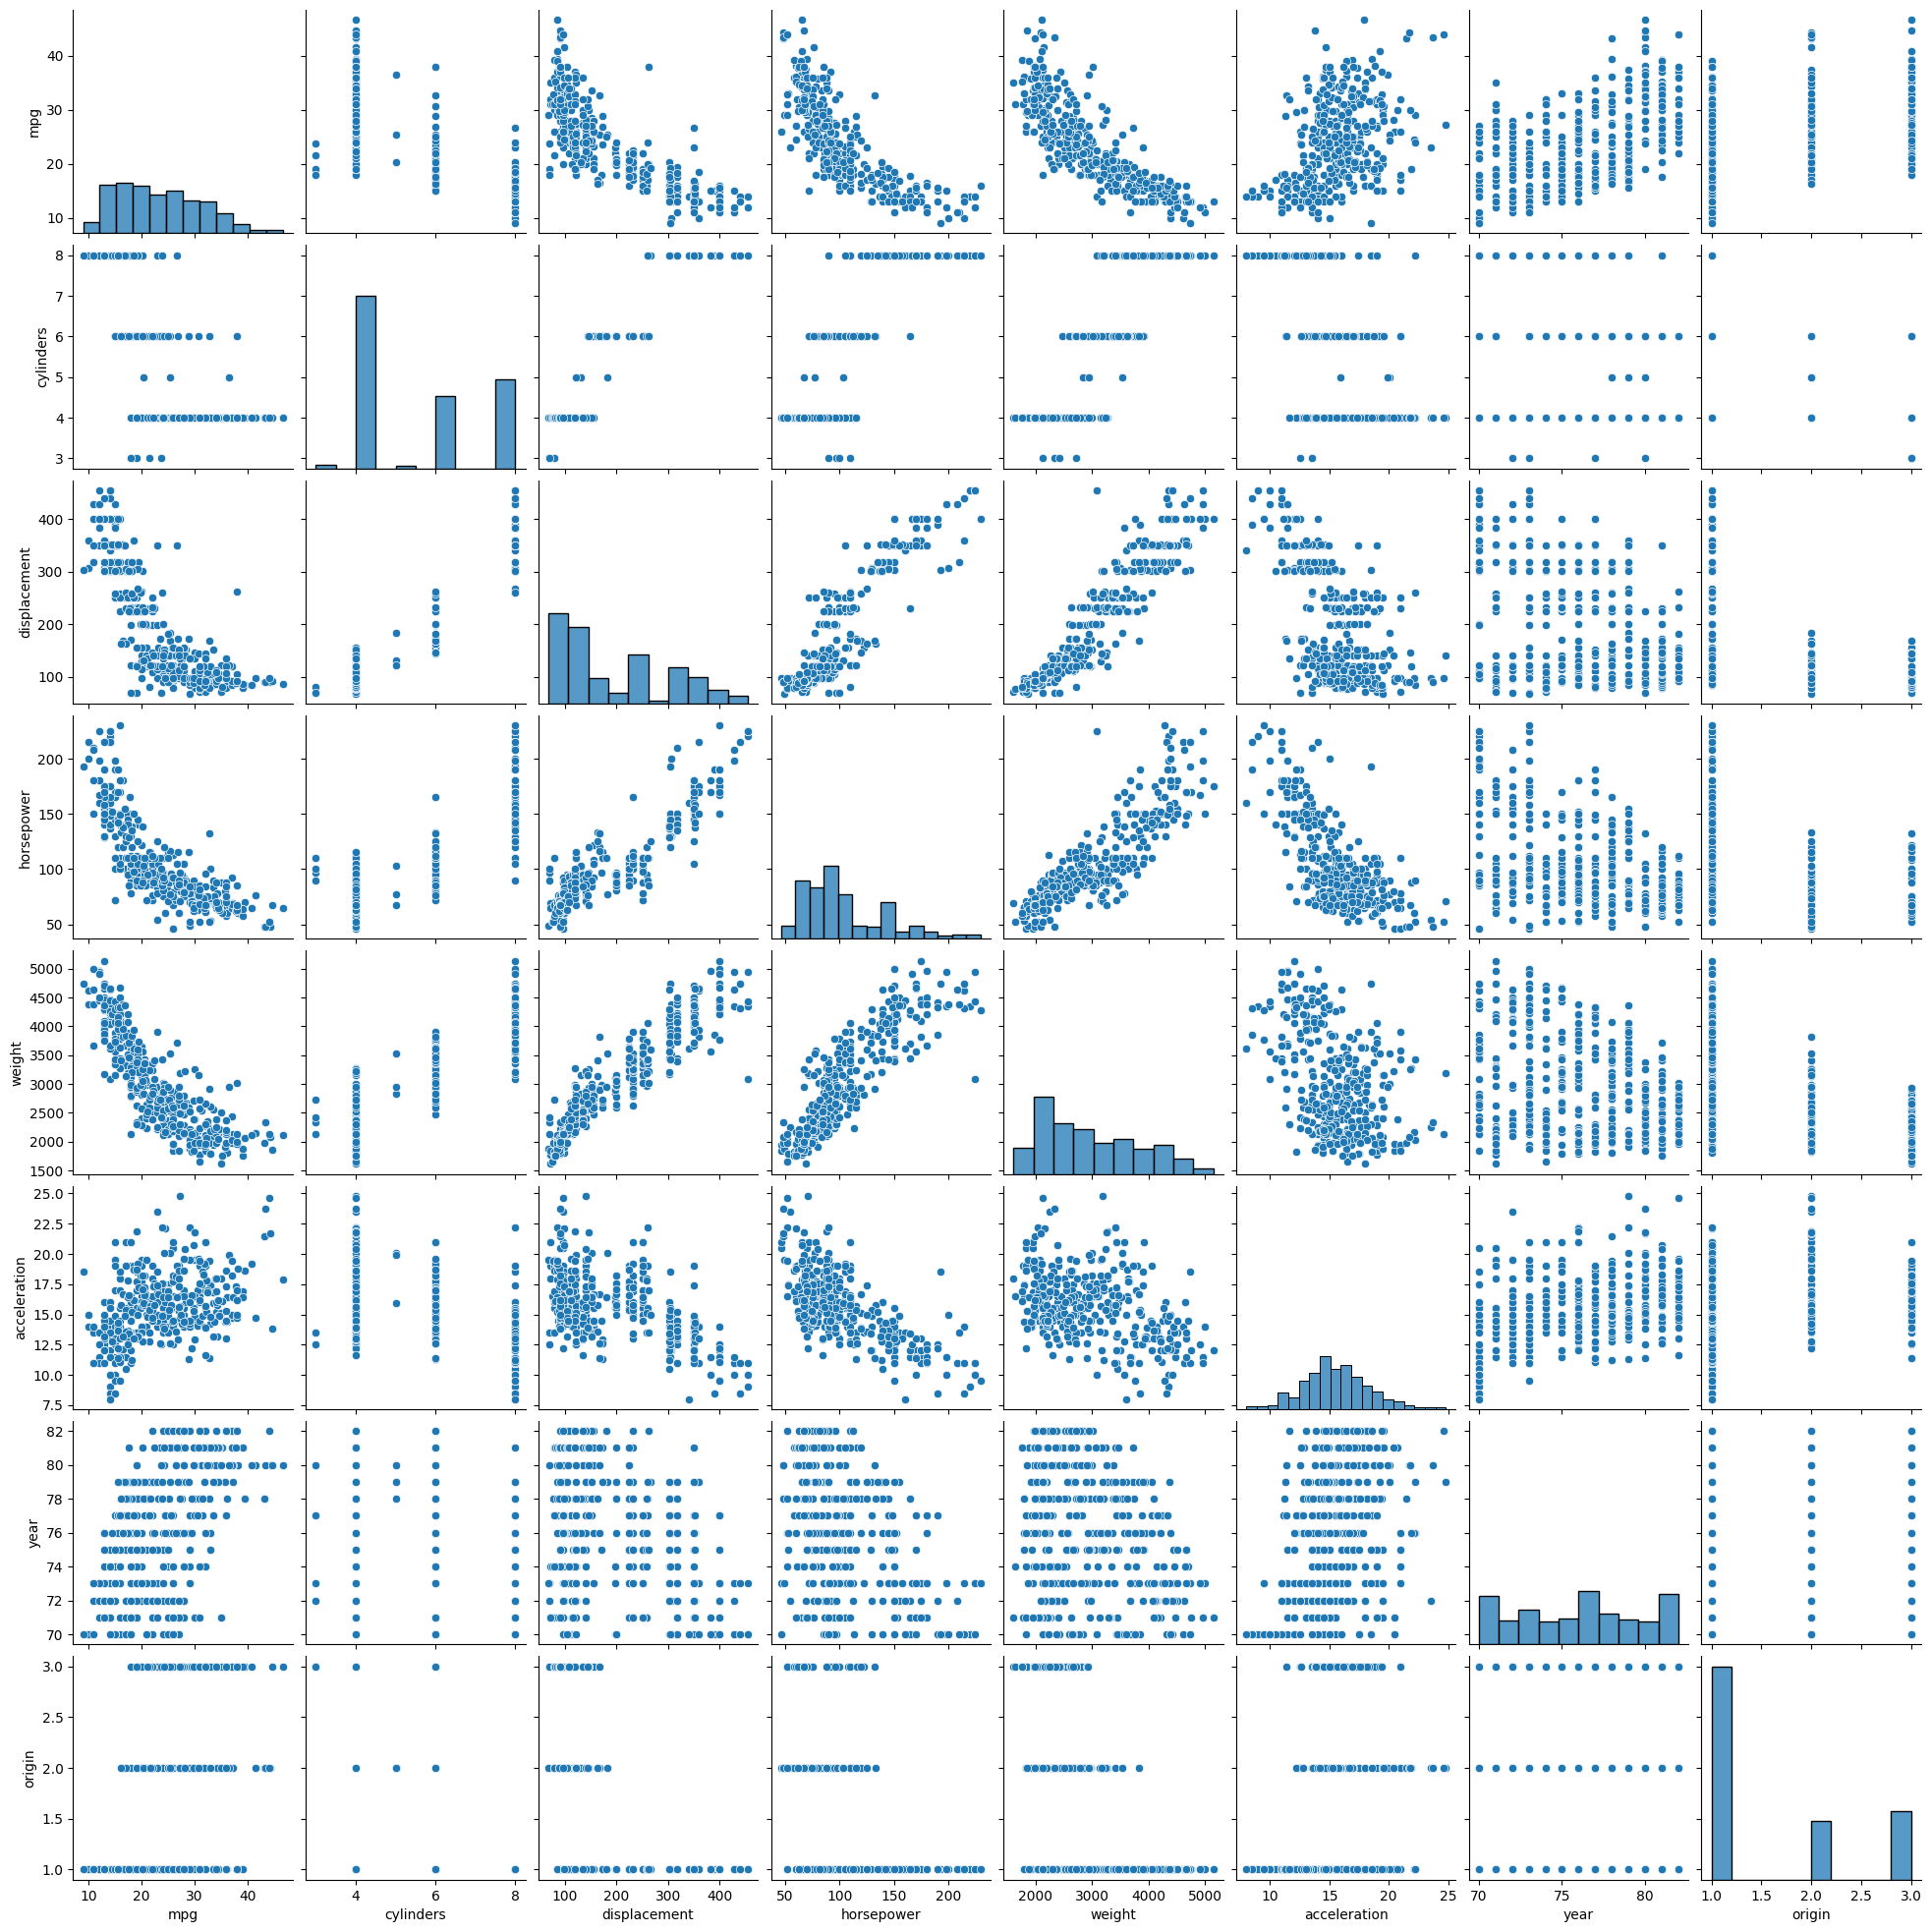

In [3]:
# Scatterplot matice obsahující proměnné
auto_numeric = auto.select_dtypes(include=[np.number])
sns.pairplot(auto_numeric)
plt.show()

In [4]:
print(f"R^2: {results.rsquared}")

R^2: 0.6059482578894348


In [5]:
# 95% interval
new_X = pd.DataFrame({"const": [1], "horsepower": [98]})
prediction = results.get_prediction(new_X);
summary = prediction.summary_frame(alpha=0.5)
print(summary)

        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  24.467077  0.251262      24.297445      24.636709     21.150765   

   obs_ci_upper  
0      27.78339  


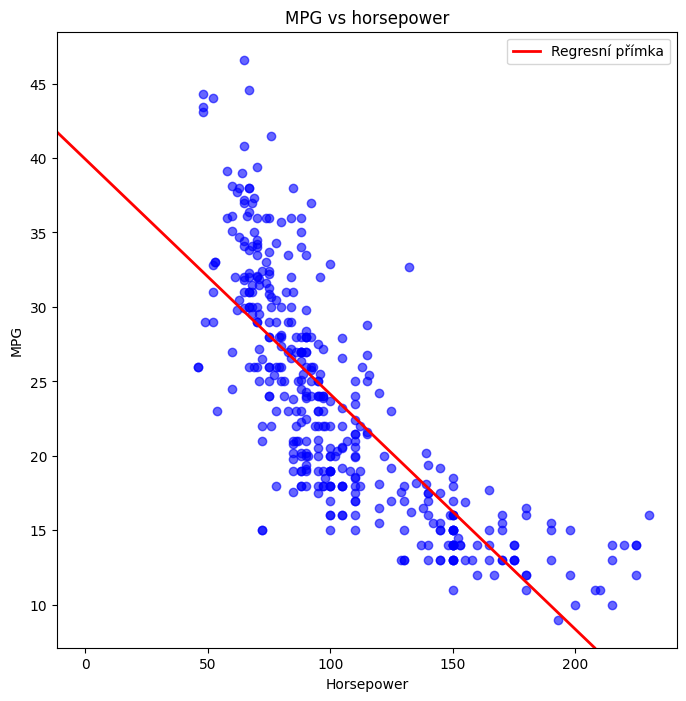

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(auto["horsepower"], auto["mpg"], color="blue", alpha=0.6)
ax.set_xlabel("Horsepower")
ax.set_ylabel("MPG")
ax.set_title("MPG vs horsepower")

intercept = results.params["const"]
slope = results.params["horsepower"]

ax.axline((0, intercept), slope=slope, color="red", linewidth=2, label="Regresní přímka")
ax.legend()
plt.show()

In [26]:
results.fittedvalues

name
chevrolet chevelle malibu    18.615353
buick skylark 320            14.673030
plymouth satellite           18.735810
amc rebel sst                15.887094
ford torino                  17.334577
                               ...    
ford mustang gl              27.508674
vw pickup                    40.450427
dodge rampage                31.454022
ford ranger                  28.453101
chevy s-10                   30.903258
Length: 392, dtype: float64

In [27]:
results.resid

name
chevrolet chevelle malibu   -0.615353
buick skylark 320            0.326970
plymouth satellite          -0.735810
amc rebel sst                0.112906
ford torino                 -0.334577
                               ...   
ford mustang gl             -0.508674
vw pickup                    3.549573
dodge rampage                0.545978
ford ranger                 -0.453101
chevy s-10                   0.096742
Length: 392, dtype: float64

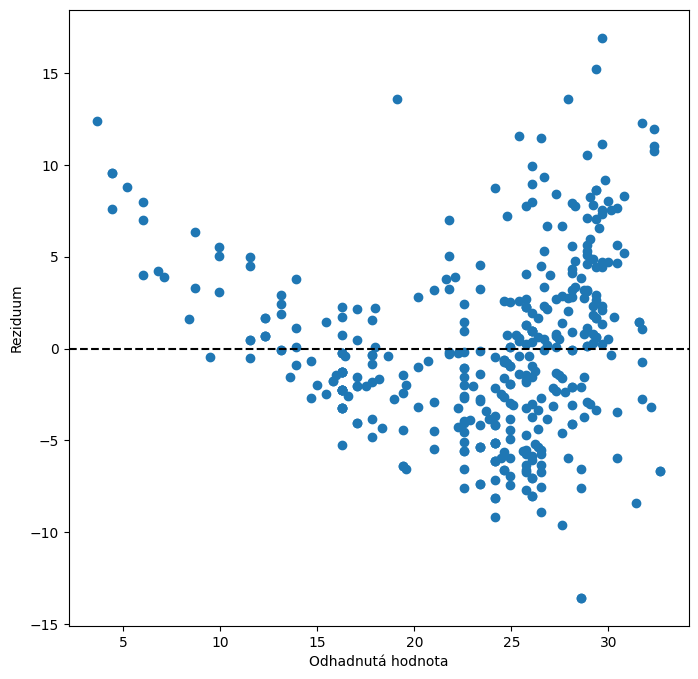

In [7]:
ax = plt.subplots(figsize=(8, 8))[1]
ax.scatter(results.fittedvalues, results.resid) # graf reziduí
ax.set_xlabel("Odhadnutá hodnota")
ax.set_ylabel("Reziduum")
ax.axhline(0, c="k", ls="--");

In [8]:
# RSS
print(sum(results.resid**2))

9385.915871932419


In [9]:
R2 = results.rsquared
adj_R2 = results.rsquared_adj

print(f"R^2: {R2}")
print(f"Upravený R^2: {adj_R2}")

R^2: 0.6059482578894348
Upravený R^2: 0.6049378688071001


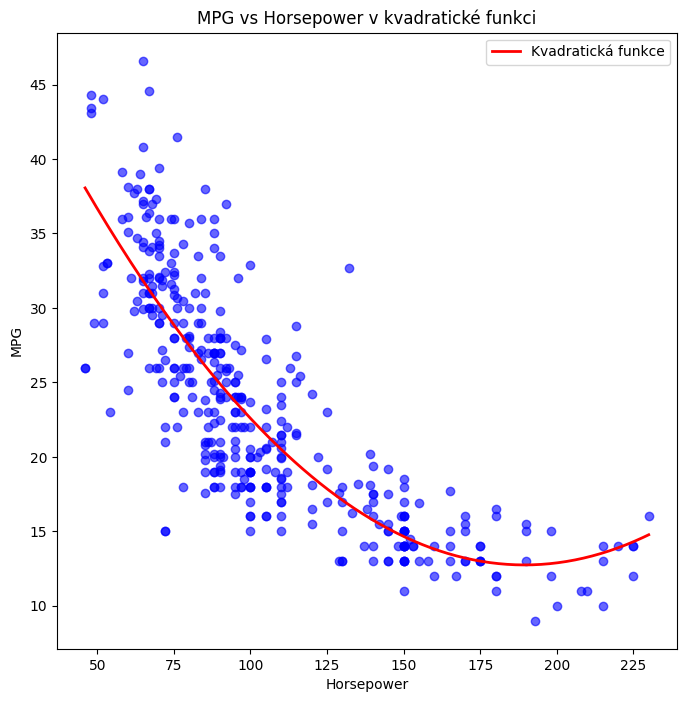

In [10]:
# Kvadratická funkce
auto["horsepower_sq"] = auto["horsepower"]**2
X_quad = sm.add_constant(auto[["horsepower", "horsepower_sq"]])
model_quad = sm.OLS(y, X_quad).fit()

# Graf kvadratické funkce
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(auto["horsepower"], auto["mpg"], color="blue", alpha=0.6)
ax.set_xlabel("Horsepower")
ax.set_ylabel("MPG")
ax.set_title("MPG vs Horsepower v kvadratické funkci")

x_vals = np.linspace(auto["horsepower"].min(), auto["horsepower"].max(), 200)
y_vals = model_quad.params["const"] + model_quad.params["horsepower"]*x_vals + model_quad.params["horsepower_sq"]*x_vals**2

ax.plot(x_vals, y_vals, color="red", linewidth=2, label="Kvadratická funkce")
ax.legend()
plt.show()


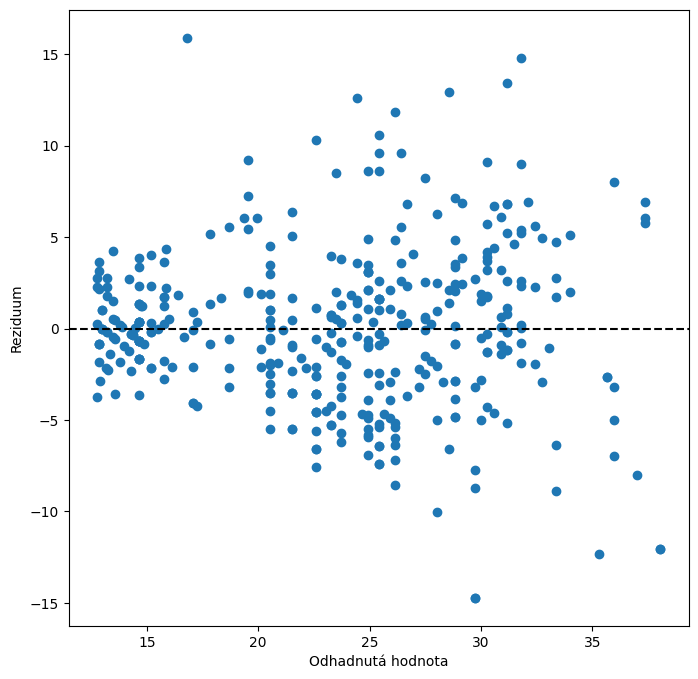

In [11]:
ax = plt.subplots(figsize=(8, 8))[1]
ax.scatter(model_quad.fittedvalues, model_quad.resid) # graf reziduí
ax.set_xlabel("Odhadnutá hodnota")
ax.set_ylabel("Reziduum")
ax.axhline(0, c="k", ls="--");

In [12]:
# RSS
print(sum(model_quad.resid**2))

7442.02941178595


In [13]:
# R^2
R2_quad = model_quad.rsquared
adj_R2 = model_quad.rsquared_adj

print(f"R^2: {R2_quad}")
print(f"Upravený R^2: {adj_R2}")

R^2: 0.6875590305127515
Upravený R^2: 0.6859526502069044


In [14]:
# Transformace kvadratické funkce
auto["log_mpg"] = np.log(auto["mpg"])

X_quad = sm.add_constant(auto[["horsepower", "horsepower_sq"]])
y_log = auto["log_mpg"]

model_quad_log = sm.OLS(y_log, X_quad).fit()
print(model_quad_log.summary())

                            OLS Regression Results                            
Dep. Variable:                log_mpg   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     532.2
Date:                Sun, 25 Jan 2026   Prob (F-statistic):          4.54e-112
Time:                        19:01:45   Log-Likelihood:                 125.48
No. Observations:                 392   AIC:                            -245.0
Df Residuals:                     389   BIC:                            -233.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.4022      0.073     60.639

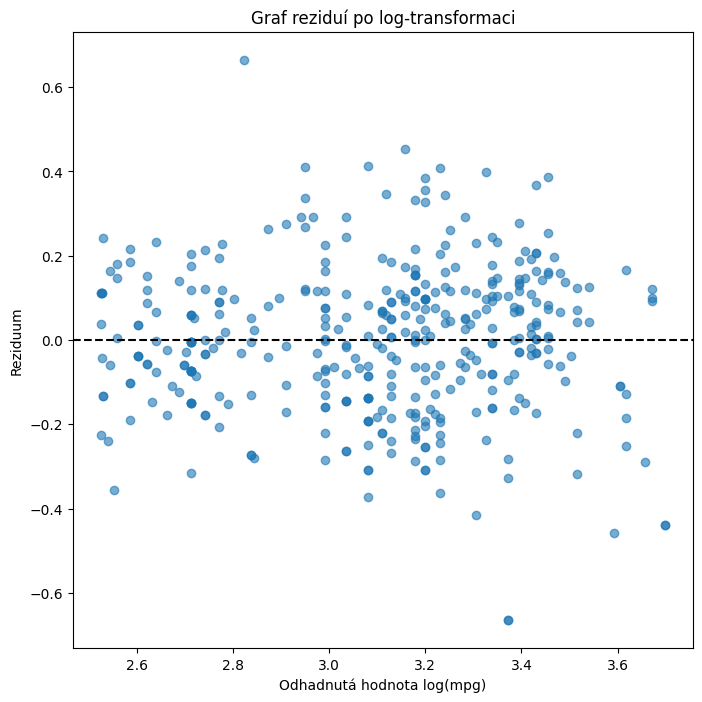

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(model_quad_log.fittedvalues, model_quad_log.resid, alpha=0.6)
ax.set_xlabel("Odhadnutá hodnota log(mpg)")
ax.set_ylabel("Reziduum")
ax.set_title("Graf reziduí po log-transformaci")
ax.axhline(0, c="k", ls="--")
plt.show()

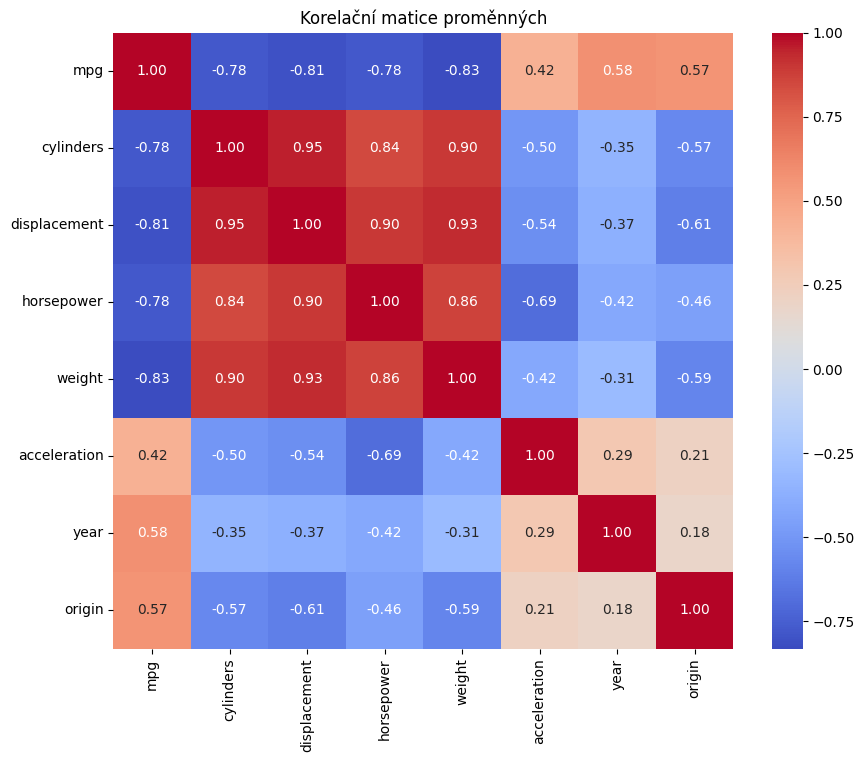

In [16]:
# Matice korelací
corr_matrix = auto_numeric.corr()
corr_matrix

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelační matice proměnných")
plt.show()

In [25]:
# OLS model se všemi prediktory kromě proměnné name
X = auto.drop(columns=["mpg"])
X = sm.add_constant(X)
y = auto["mpg"]

model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     2162.
Date:                Sun, 25 Jan 2026   Prob (F-statistic):          1.74e-321
Time:                        19:19:45   Log-Likelihood:                -586.96
No. Observations:                 392   AIC:                             1194.
Df Residuals:                     382   BIC:                             1234.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -52.6630      2.005    -26.260      0.000     -56.606     -48.720
cylinders         0.5321      0.111      4.778      0.000       0.313       0.751
displacement     -0.0068      0.003     -2.524      0.012      -0.012      -0.002
horsepower       -0.1030      0.013     -7.761      0.000      -0.129      -0.077
weight            0.0011      0.000      4.094      0.000       0.001       0.002
acceleration     -0.0525      0.037     -1.431      0.153      -0.124       0.020
year              0.0193      0.022      0.875      0.382      -0.024       0.063
origin            0.2616      0.094      2.778      0.006       0.076       0.447
horsepower_sq     0.0004   4.07e-05      9.986      0.000       0.000       0.000
log_mpg          24.5212      0.491     49.906      0.000      23.555      25.487
==============================================================================
Omnibus:                       79.506   Durbin-Watson:                   1.409
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              202.032
Skew:                           0.985   Prob(JB):                     1.35e-44
Kurtosis:                       5.913   Cond. No.                     5.87e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.87e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [29]:
print("F-statistika:", results.fvalue)
print("p-hodnota F-testu:", results.f_pvalue)

F-statistika: 2162.259523492941
p-hodnota F-testu: 1.74e-321


In [30]:
print("R²:", results.rsquared)
print("Adjusted R²:", results.rsquared_adj)

R²: 0.9807482342020941
Adjusted R²: 0.980294658568112


In [32]:
results.pvalues

const             1.396489e-87
cylinders         2.529215e-06
displacement      1.200285e-02
horsepower        7.802467e-14
weight            5.166883e-05
acceleration      1.531239e-01
year              3.823867e-01
origin            5.731914e-03
horsepower_sq     5.097679e-21
log_mpg          1.920842e-169
dtype: float64

In [18]:
results.fvalue

np.float64(2162.259523492941)

In [19]:
# P-hodnota je blízká nule, tedy proměnné jsou na sobě závislé, nulovou hypotézu lze vyvrátit
results.f_pvalue

np.float64(1.74e-321)

In [20]:
results.pvalues

const             1.396489e-87
cylinders         2.529215e-06
displacement      1.200285e-02
horsepower        7.802467e-14
weight            5.166883e-05
acceleration      1.531239e-01
year              3.823867e-01
origin            5.731914e-03
horsepower_sq     5.097679e-21
log_mpg          1.920842e-169
dtype: float64

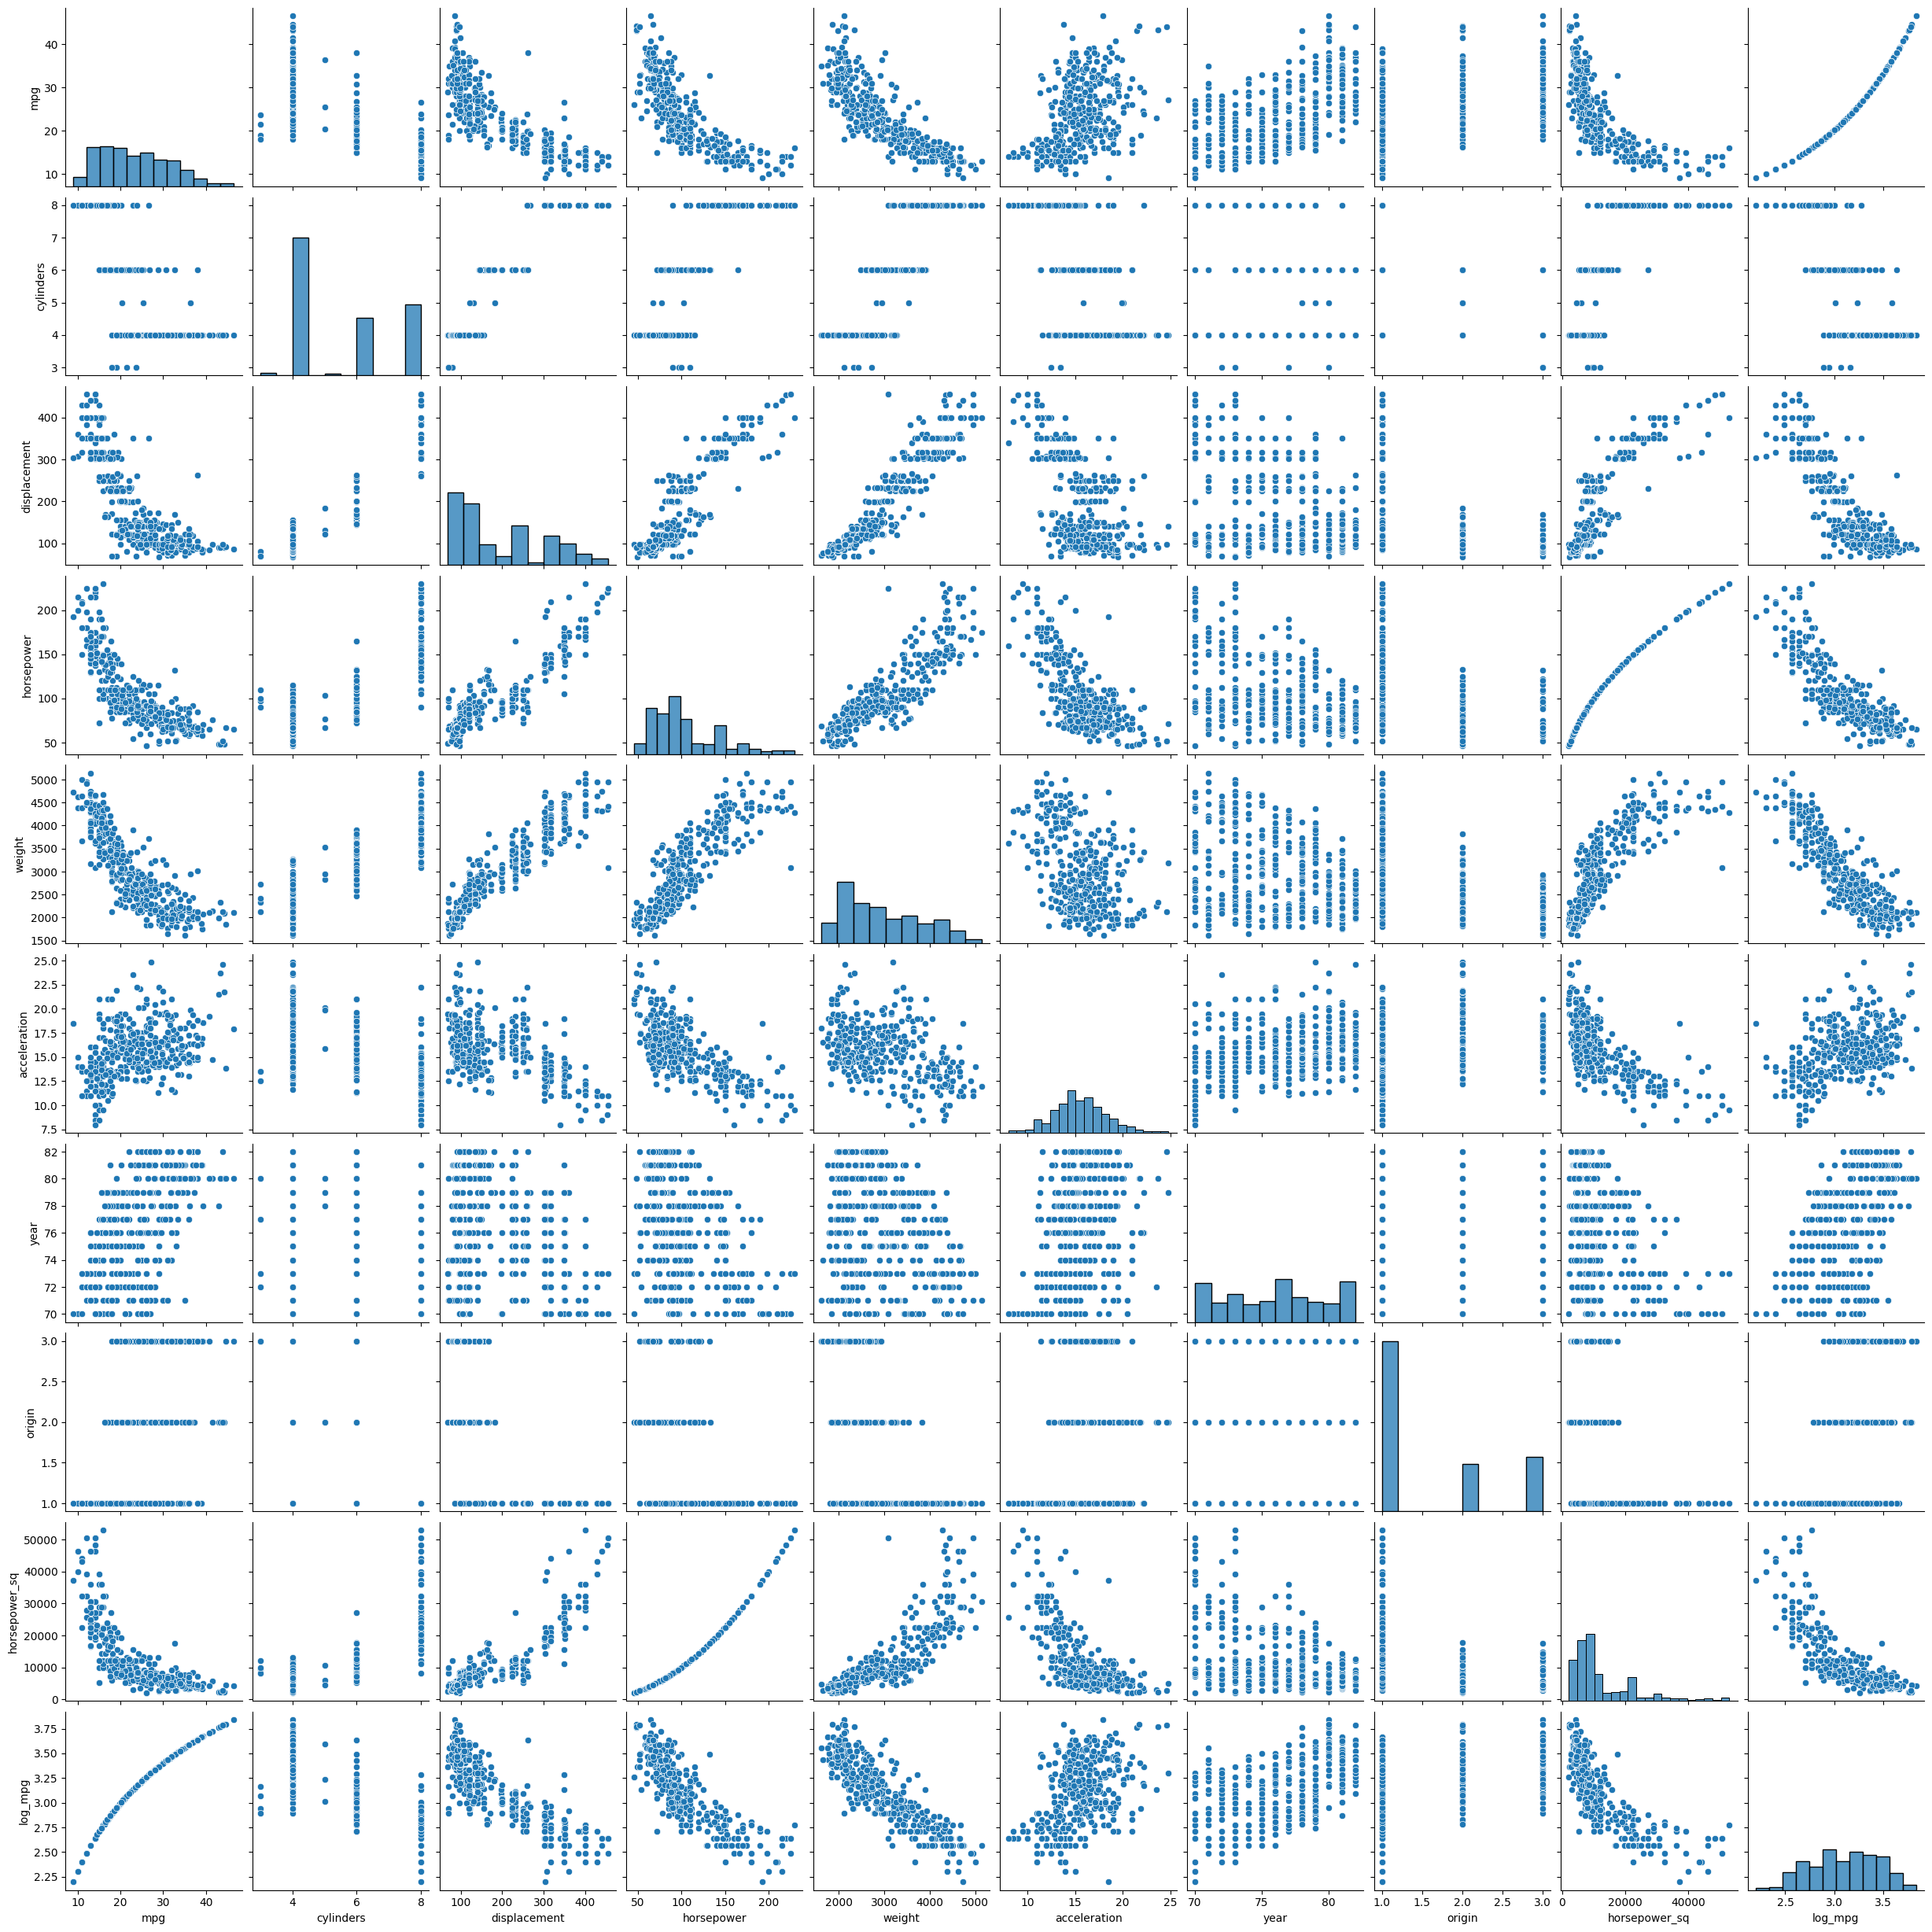

In [28]:
sns.pairplot(auto)